# 02 — Eksploracyjna analiza danych (EDA)

## Cel

W tym notebooku poznaję dane przed modelowaniem.

Żeby nie podglądać przyszłego testu, EDA wykonuję tylko na części treningowej.

## 1. Importy i odtworzenie podziału

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

DATA_PATH = Path("dane/5year_cleaned.csv")

df = pd.read_csv(DATA_PATH)
feature_cols = [col for col in df.columns if col != "class"]

# Odtwarzam dokładnie ten sam podział co w notebooku 01.
development, test = train_test_split(
    df,
    test_size=0.20,
    stratify=df["class"],
    random_state=42
)

train, validation = train_test_split(
    development,
    test_size=0.20,
    stratify=development["class"],
    random_state=42
)

# EDA wykonuję wyłącznie na treningu.
print("EDA wykonuję na treningu:", train.shape)

EDA wykonuję na treningu: (3744, 65)


## 2. Rozkład klas

,count,percent
class,,
0,3483,93.03
1,261,6.97


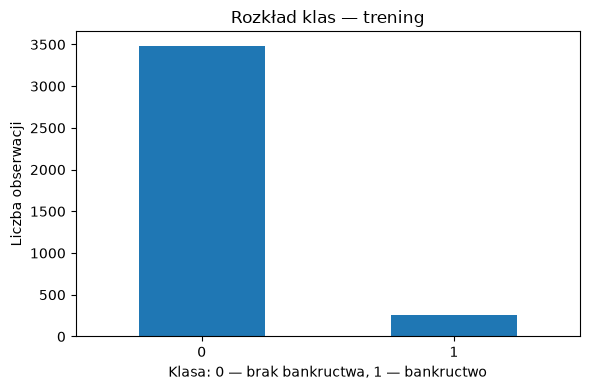

In [2]:
# Liczba i udział procentowy obu klas w treningu.
counts = train["class"].value_counts().sort_index()
percent = train["class"].value_counts(normalize=True).sort_index() * 100

display(pd.DataFrame({
    "count": counts,
    "percent": percent.round(2)
}))

# Prosty wykres pokazuje skalę niezbalansowania.
plt.figure(figsize=(6, 4))
counts.plot(kind="bar")
plt.title("Rozkład klas — trening")
plt.xlabel("Klasa: 0 — brak bankructwa, 1 — bankructwo")
plt.ylabel("Liczba obserwacji")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Wniosek

W treningu jest **3483 firm z klasy 0** i tylko **261 z klasy 1**. Proporcja jest więc prawie taka sama jak w całym zbiorze.

Model przewidujący prawie zawsze `0` mógłby mieć wysoką `accuracy`, dlatego szczególnie ważne będą metryki pokazujące jakość wykrywania bankructw.

## 3. Statystyki opisowe

In [3]:
# describe() daje podstawowe statystyki dla wszystkich 64 cech.
describe_features = train[feature_cols].describe().T

# Dodaję medianę, ponieważ przy skośnych danych jest często bardziej czytelna niż średnia.
describe_features["median"] = train[feature_cols].median()

display(
    describe_features[
        ["count", "mean", "median", "std", "min", "25%", "50%", "75%", "max"]
    ].round(2)
)

,count,mean,median,std,min,25%,50%,75%,max
Attr1,3743.0,-0.06,0.05,7.72,-463.89,0.00,0.05,0.12,87.46
Attr2,3743.0,0.42,0.45,7.12,-430.87,0.26,0.45,0.67,46.03
Attr3,3743.0,0.20,0.22,0.68,-24.66,0.04,0.22,0.42,17.63
Attr4,3733.0,5.74,1.66,113.80,0.00,1.09,1.66,2.97,6845.80
Attr5,3740.0,27.27,0.36,27023.84,-1076400.00,-45.34,0.36,48.61,1250100.00
...,...,...,...,...,...,...,...,...,...
Attr60,3581.0,1392.76,8.73,80525.29,0.06,5.18,8.73,17.16,4818700.00
Attr61,3734.0,11.04,6.28,43.69,0.02,4.39,6.28,9.32,1308.50
Attr62,3744.0,132.25,73.43,712.67,0.00,44.66,73.43,118.89,25380.00
Attr63,3733.0,10.02,4.96,128.41,0.00,3.07,4.96,8.11,7641.30


### Wniosek

W wielu cechach średnia mocno różni się od mediany. Przykładowo `Attr60` ma średnią ponad **1390**, ale medianę tylko około **8,7**.

Tak duże różnice wskazują na skośne rozkłady i wpływ wartości skrajnych. Dlatego przy opisie tych danych nie warto patrzeć wyłącznie na średnią.

## 4. Histogramy wszystkich 64 cech

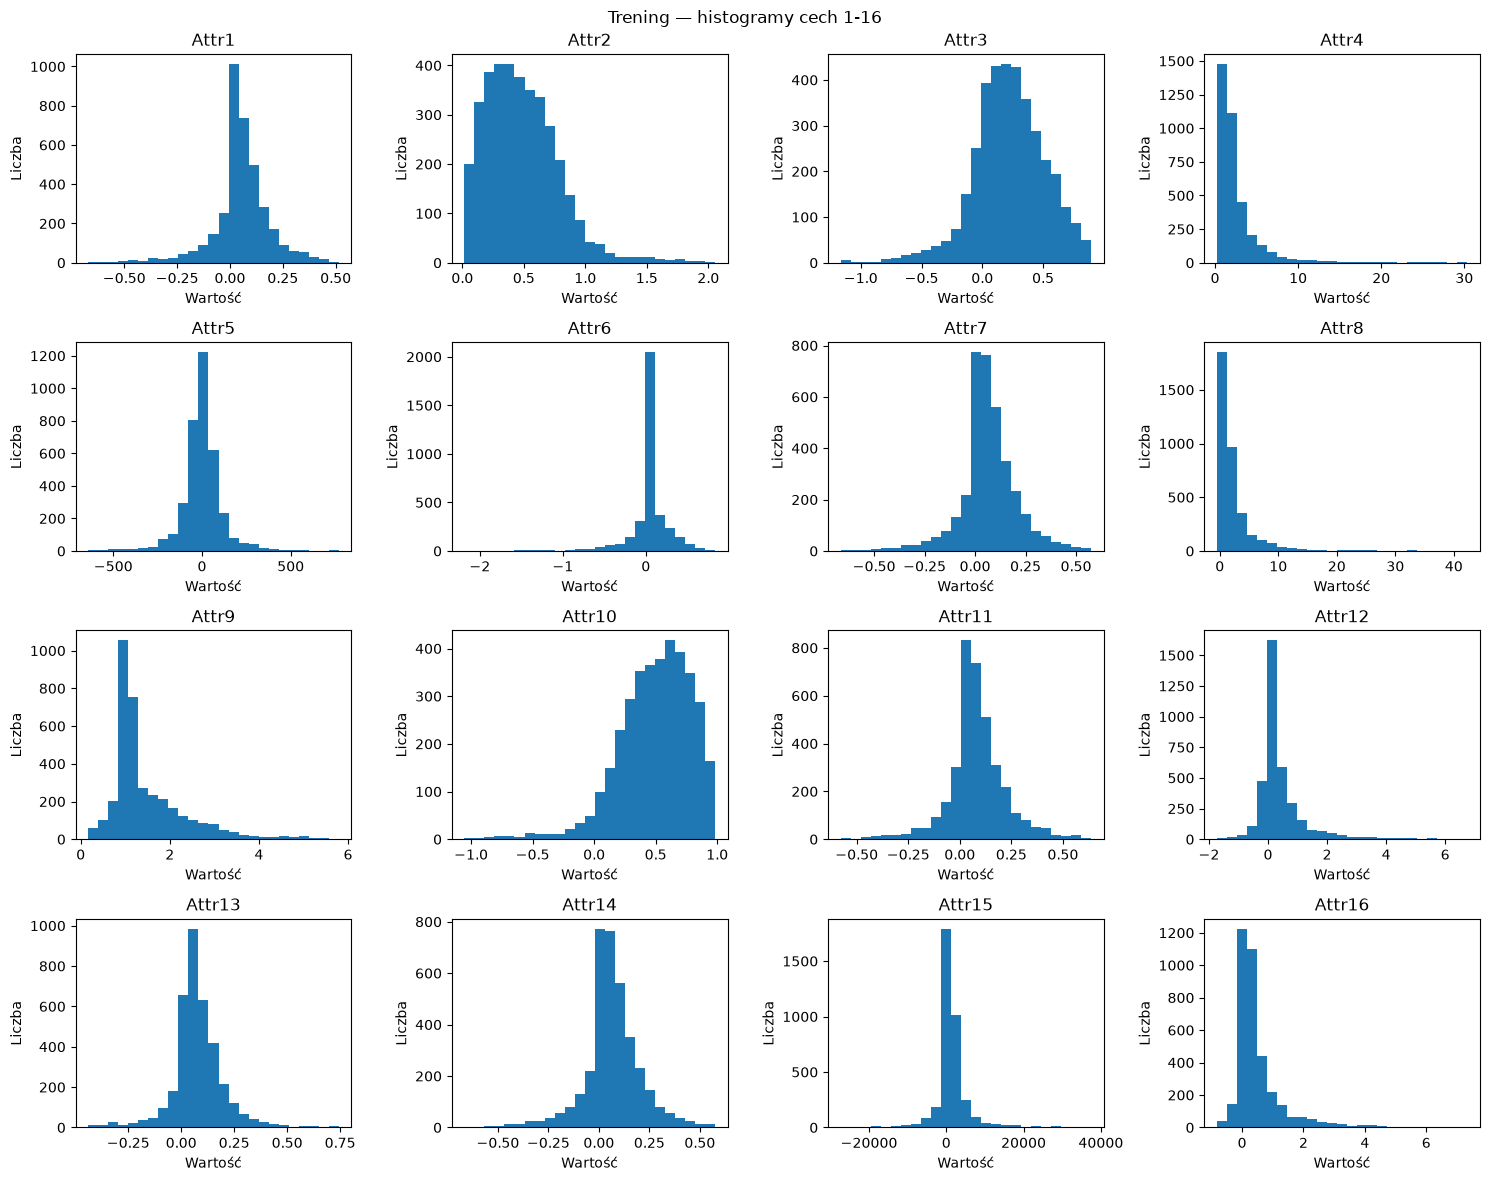

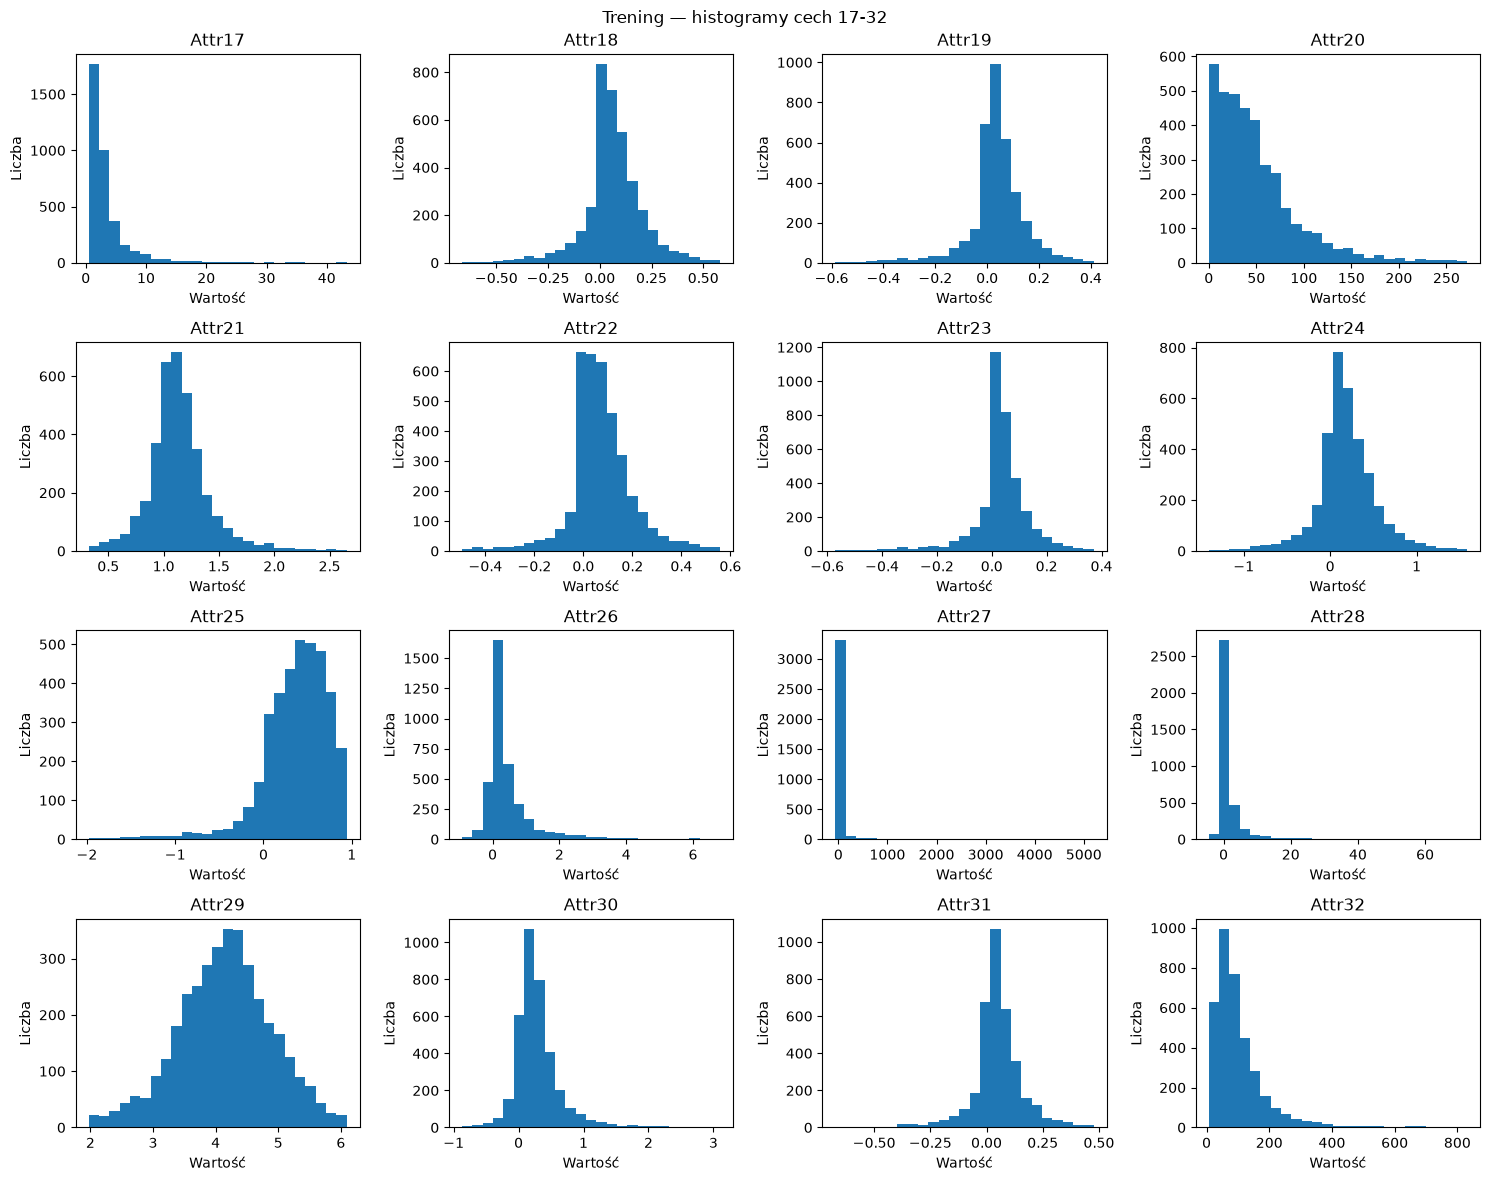

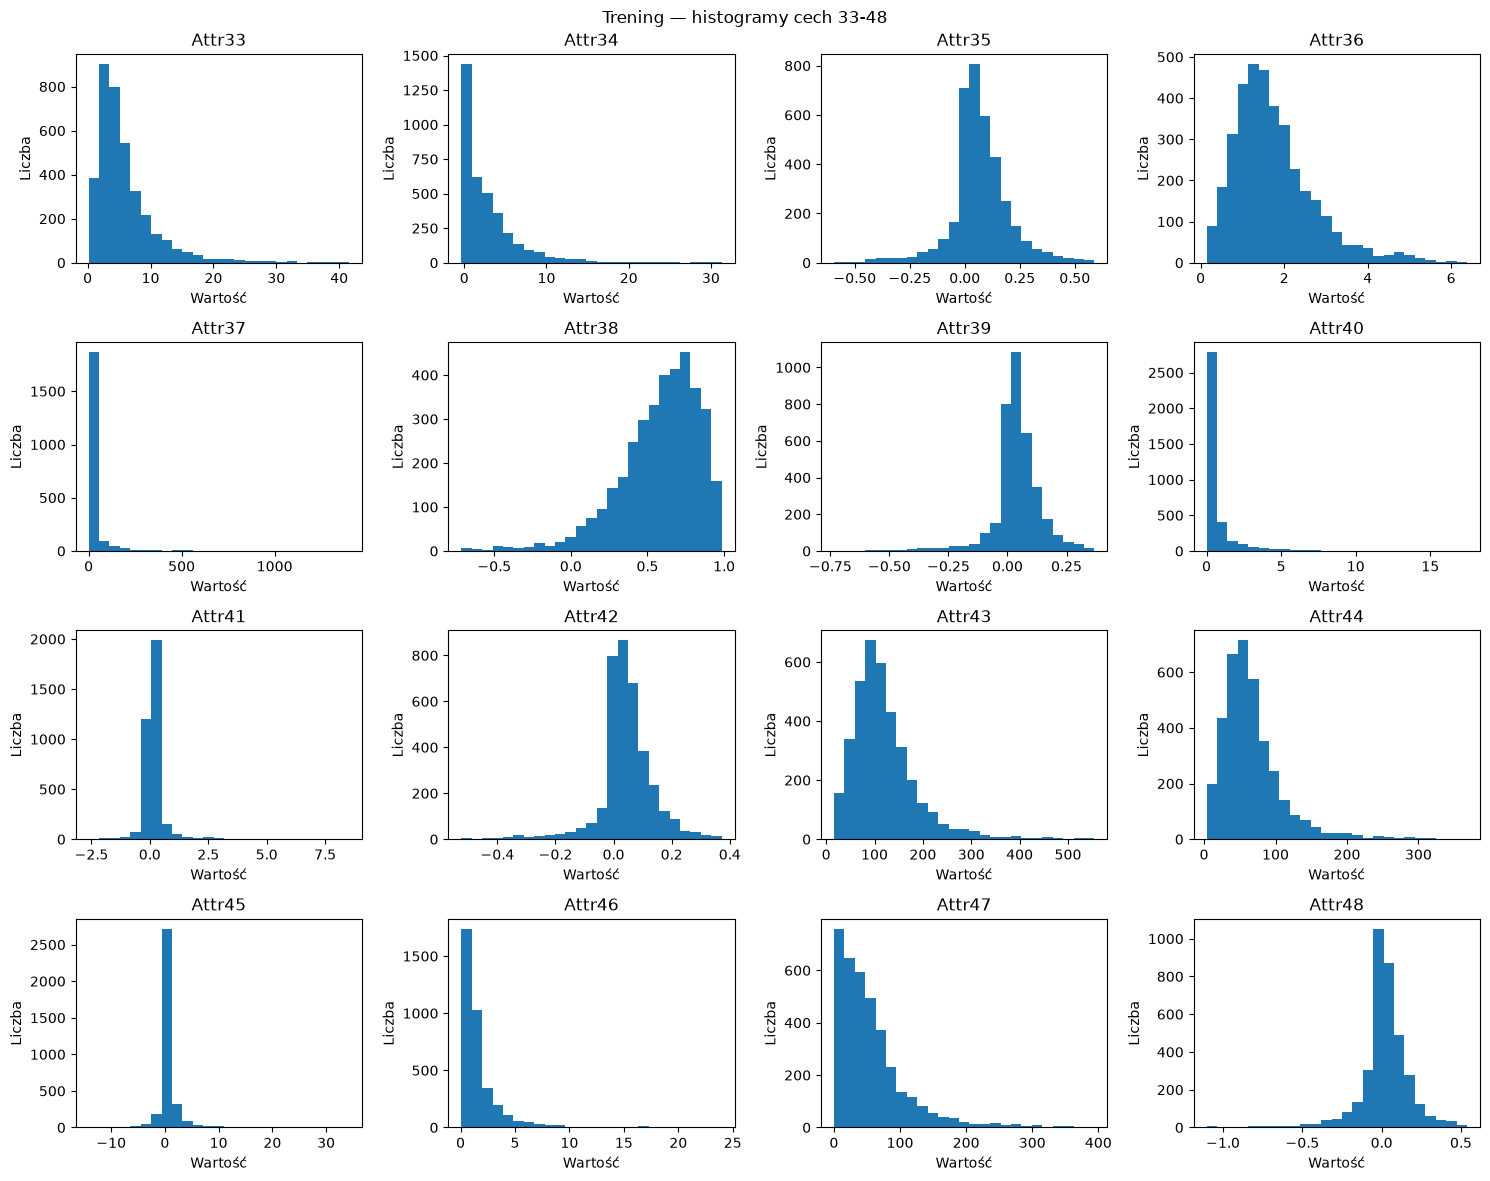

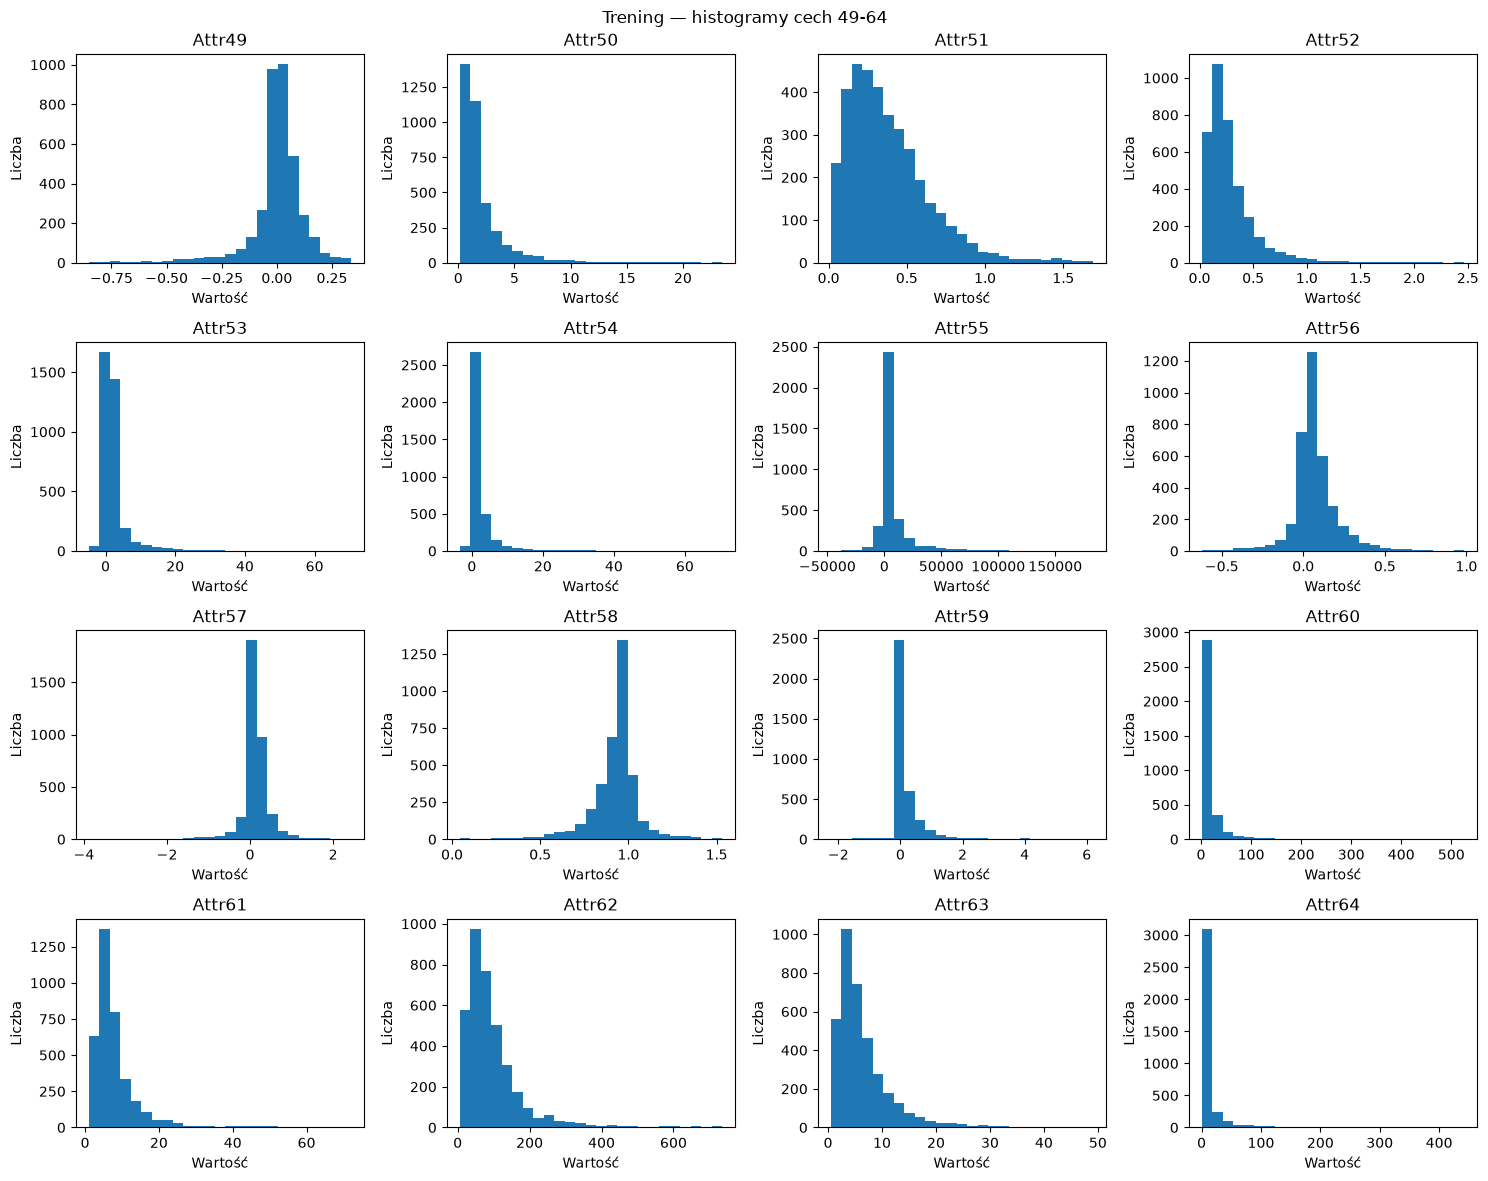

In [4]:
# Dzielę 64 cechy na cztery czytelne plansze po 16 histogramów.
# Do samego wykresu ograniczam zakres do q01-q99, żeby pojedyncze skrajne wartości
# nie ścisnęły całego histogramu. Dane w zbiorze nie są przez to usuwane.

# Pętla tworzy kolejne grupy: 1-16, 17-32, 33-48 i 49-64.
for start in range(0, len(feature_cols), 16):
    selected = feature_cols[start:start + 16]

    fig, axes = plt.subplots(4, 4, figsize=(15, 12))
    axes = axes.ravel()

    for ax, feature in zip(axes, selected):
        lower = train[feature].quantile(0.01)
        upper = train[feature].quantile(0.99)

        values = train.loc[
            train[feature].between(lower, upper),
            feature
        ].dropna()

        ax.hist(values, bins=25)
        ax.set_title(feature)
        ax.set_xlabel("Wartość")
        ax.set_ylabel("Liczba")

    for ax in axes[len(selected):]:
        ax.axis("off")

    fig.suptitle(f"Trening — histogramy cech {start + 1}-{start + len(selected)}")
    plt.tight_layout()
    plt.show()

### Wniosek

Histogramy potwierdzają, że cechy mają bardzo różne kształty. Część jest skupiona w wąskim zakresie, a część ma długie ogony.

Widać też dużo rozkładów prawoskośnych, np. dla `Attr4`, `Attr17`, `Attr27`, `Attr60` czy `Attr64`.

Zakres `q01–q99` jest używany tylko do czytelniejszego rysowania. Wartości poza tym zakresem nadal pozostają w danych.

## 5. Braki danych a klasa

,srednia_liczba_brakow,udzial_firm_z_brakiem
class,,
0,0.71,46.22
1,1.45,71.26


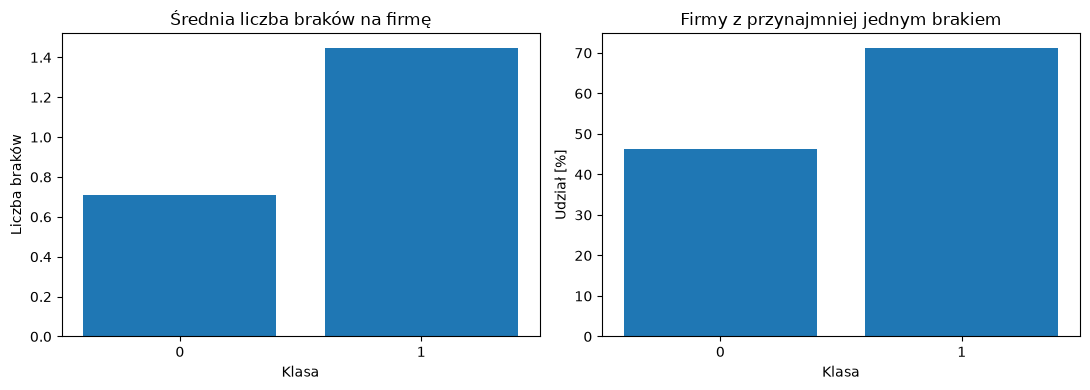

In [5]:
# Dla każdego wiersza liczę, ilu wartości brakuje.
missing_count = train[feature_cols].isna().sum(axis=1)

# has_missing = 1, gdy firma ma przynajmniej jeden brak.
missing_by_class = pd.DataFrame({
    "class": train["class"],
    "missing_count": missing_count,
    "has_missing": (missing_count > 0).astype(int)
}).groupby("class").agg(
    srednia_liczba_brakow=("missing_count", "mean"),
    udzial_firm_z_brakiem=("has_missing", "mean")
)

# Zamieniam udział z 0-1 na procent.
missing_by_class["udzial_firm_z_brakiem"] *= 100
display(missing_by_class.round(2))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(
    missing_by_class.index.astype(str),
    missing_by_class["srednia_liczba_brakow"]
)
axes[0].set_title("Średnia liczba braków na firmę")
axes[0].set_xlabel("Klasa")
axes[0].set_ylabel("Liczba braków")

axes[1].bar(
    missing_by_class.index.astype(str),
    missing_by_class["udzial_firm_z_brakiem"]
)
axes[1].set_title("Firmy z przynajmniej jednym brakiem")
axes[1].set_xlabel("Klasa")
axes[1].set_ylabel("Udział [%]")

plt.tight_layout()
plt.show()

### Wniosek

Braki danych wyraźnie częściej występują przy bankructwach:

- klasa `0`: średnio **0,71** braku na firmę, a przynajmniej jeden brak ma około **46%** firm,
- klasa `1`: średnio **1,45** braku, a przynajmniej jeden brak ma około **71%** firm.

Dlatego w modelowaniu zachowuję informację o brakach przez `missing_count`, `has_missing` oraz wskaźniki braków dodawane przez imputer.

## 6. Korelacja cech z targetem

In [6]:
# Pearson mierzy liniową zależność każdej cechy z targetem 0/1.
target_corr = (
    train[feature_cols + ["class"]]
    .corr(method="pearson")["class"]
    .drop("class")
)

# Sortuję po wartości bezwzględnej, bo ważny jest zarówno kierunek dodatni, jak i ujemny.
target_corr_table = pd.DataFrame({
    "correlation": target_corr,
    "abs_correlation": target_corr.abs()
}).sort_values("abs_correlation", ascending=False)

display(target_corr_table.head(10).round(3))

,correlation,abs_correlation
Attr39,-0.215,0.215
Attr56,-0.198,0.198
Attr51,0.170,0.170
Attr3,-0.166,0.166
Attr29,-0.166,0.166
Attr62,0.131,0.131
Attr58,0.127,0.127
Attr30,0.097,0.097
Attr57,-0.078,0.078
Attr43,0.070,0.070


### Wniosek

Największe zależności liniowe z targetem mają:

- `Attr39`: **-0,215**,
- `Attr56`: **-0,198**,
- `Attr51`: **0,170**.

To nadal niezbyt wysokie korelacje. Nie ma jednej cechy, która sama dobrze oddziela obie klasy. Model będzie musiał korzystać z wielu wskaźników jednocześnie.

## 7. Boxploty trzech cech najbardziej związanych z targetem

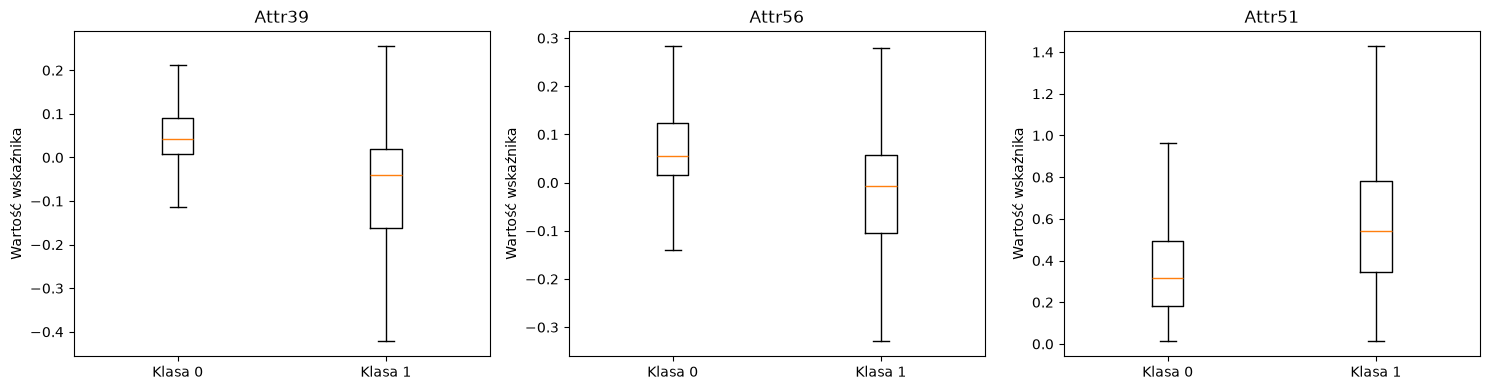

In [7]:
# Wybieram 3 cechy o największej bezwzględnej korelacji z targetem.
chosen_features = target_corr_table.head(3).index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, feature in zip(axes, chosen_features):
    lower = train[feature].quantile(0.01)
    upper = train[feature].quantile(0.99)

    # Rozdzielam wartości na dwie klasy.
    # q01-q99 ogranicza tylko zakres prezentowany na wykresie.
    class_0 = train.loc[
        (train["class"] == 0) & train[feature].between(lower, upper),
        feature
    ].dropna()

    class_1 = train.loc[
        (train["class"] == 1) & train[feature].between(lower, upper),
        feature
    ].dropna()

    ax.boxplot([class_0, class_1], showfliers=False)
    ax.set_xticks([1, 2], ["Klasa 0", "Klasa 1"])
    ax.set_title(feature)
    ax.set_ylabel("Wartość wskaźnika")

plt.tight_layout()
plt.show()

### Wniosek

Na boxplotach widać kierunek wcześniejszych korelacji:

- `Attr39` i `Attr56` mają niższe typowe wartości w klasie `1`,
- `Attr51` ma wyższe typowe wartości w klasie `1`.

Pudełka nadal mocno się nakładają, więc żadna z tych cech nie wystarcza sama do klasyfikacji.

## 8. Korelacje między cechami

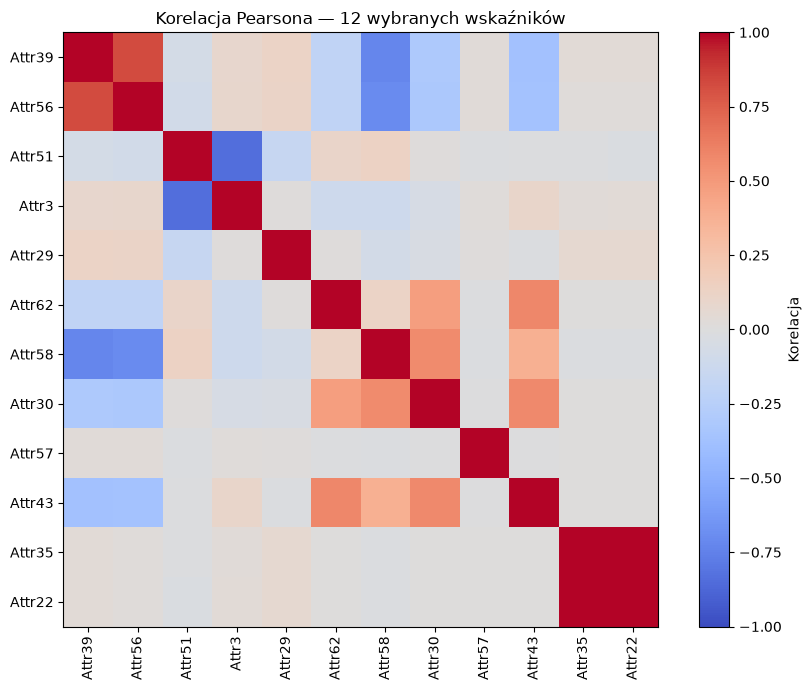

,feature_1,feature_2,correlation,abs_correlation
369,Attr7,Attr14,1.0,1.0
428,Attr8,Attr17,1.0,1.0
849,Attr16,Attr26,1.0,1.0
1840,Attr45,Attr60,1.0,1.0
595,Attr11,Attr22,1.0,1.0
227,Attr4,Attr46,1.0,1.0
1125,Attr22,Attr35,1.0,1.0
608,Attr11,Attr35,1.0,1.0
1138,Attr22,Attr48,1.0,1.0
621,Attr11,Attr48,1.0,1.0


In [8]:
# Do czytelnej macierzy wybieram 12 cech najbardziej związanych z targetem.
top_features = target_corr_table.head(12).index.tolist()
corr_matrix = train[top_features].corr()

plt.figure(figsize=(9, 7))
plt.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Korelacja")

plt.xticks(range(len(top_features)), top_features, rotation=90)
plt.yticks(range(len(top_features)), top_features)

plt.title("Korelacja Pearsona — 12 wybranych wskaźników")
plt.tight_layout()
plt.show()

# Pełną macierz 64x64 liczę osobno, ale zamiast dużego wykresu
# pokazuję tylko 10 najsilniej skorelowanych par.
full_corr = train[feature_cols].corr()
pairs = []

# i < j pomija przekątną oraz powtórzenia typu A-B i B-A.
for i in range(len(feature_cols)):
    for j in range(i + 1, len(feature_cols)):
        f1 = feature_cols[i]
        f2 = feature_cols[j]
        value = full_corr.loc[f1, f2]

        pairs.append({
            "feature_1": f1,
            "feature_2": f2,
            "correlation": value,
            "abs_correlation": abs(value)
        })

pairs = (
    pd.DataFrame(pairs)
    .sort_values("abs_correlation", ascending=False)
)

display(pairs.head(10).round(3))

### Wniosek

Występują pary cech o korelacji zaokrąglającej się nawet do **1,000**, np. `Attr7–Attr14`, `Attr8–Attr17` czy `Attr16–Attr26`.

Oznacza to, że część wskaźników zmienia się bardzo podobnie i może zawierać podobną informację. Nie usuwam ich automatycznie, ponieważ później porównuję modele o różnym sposobie działania.

## Podsumowanie EDA

Najważniejsze obserwacje:

- klasa `1` stanowi tylko około **7%** treningu,
- wiele cech ma skośne rozkłady i mocne wartości skrajne,
- braki danych są wyraźnie częstsze w klasie `1`,
- pojedyncze cechy mają tylko umiarkowaną lub słabą zależność liniową z targetem,
- część cech jest bardzo mocno skorelowana ze sobą.

EDA nie wskazuje jednej prostej reguły oddzielającej bankructwa od pozostałych firm. Następny krok to porównanie kilku różnych modeli na tych samych danych.